In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy


def rbf(x1: np.ndarray, x2: np.ndarray, sigma2: float = 1.0, l: float = 1.0) -> np.ndarray:
    if x2 is None:
        x2 = x1
    return sigma2 * np.exp(-0.5 * ((x1[:,None] - x2[None,:]) / l)**2)


class GaussianProcess:
    def __init__(self, m, k, sigma2_noise: float = 0.0):
        self.m = m
        self.k = k
        self.sigma2_noise = sigma2_noise

    def sample(self, x: np.ndarray) -> np.ndarray:
        return np.random.multivariate_normal(self.m(x), self.k(x, x))

    def observe(self, x: np.ndarray, y: np.ndarray):
        old_m = self.m
        old_k = self.k

        # Update m.
        A = self.k(x, x) + self.sigma2_noise*np.identity(x.shape[0])
        L = np.linalg.cholesky(A, upper=False)

        a = scipy.linalg.solve_triangular(L, y - self.m(x), lower=True)
        b = scipy.linalg.solve_triangular(L.T, a, lower=False)

        def new_m(x_new: np.ndarray) -> np.ndarray:
            return old_m(x_new) + old_k(x_new, x) @ b
        self.m = new_m

        # Update k.
        def new_k(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
            a = scipy.linalg.solve_triangular(L, old_k(x, x2), lower=True)
            b = scipy.linalg.solve_triangular(L.T, a, lower=False)
            return old_k(x1, x2) - old_k(x1, x) @ b
        self.k = new_k

    def plot(self, ax, x_new: np.ndarray):
        mu_new = self.m(x_new)
        ax.plot(x_new, mu_new, "k", label=r"$\mu$")

        sigma2_new = np.diag(self.k(x_new, x_new))
        eps = 1e-8
        sigma_new = np.sqrt(sigma2_new + eps)
        ax.fill_between(x_new, mu_new - 2*sigma_new, mu_new + 2*sigma_new, color="blue", alpha=0.3, label=r"$\mu \pm 2\sigma$")

    def plot_k(self, ax, x_new: np.ndarray):
        img = ax.imshow(self.k(x_new, x_new))
        return img

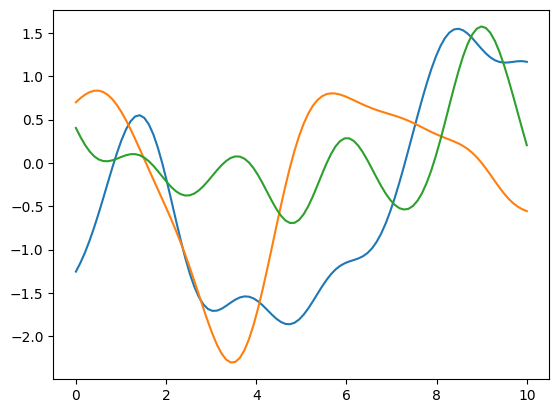

In [2]:
m = np.zeros_like
k = rbf
gp = GaussianProcess(m=m, k=k)

x = np.linspace(0, 10, 100)
for i in range(3):
    plt.plot(x, gp.sample(x))
plt.show()

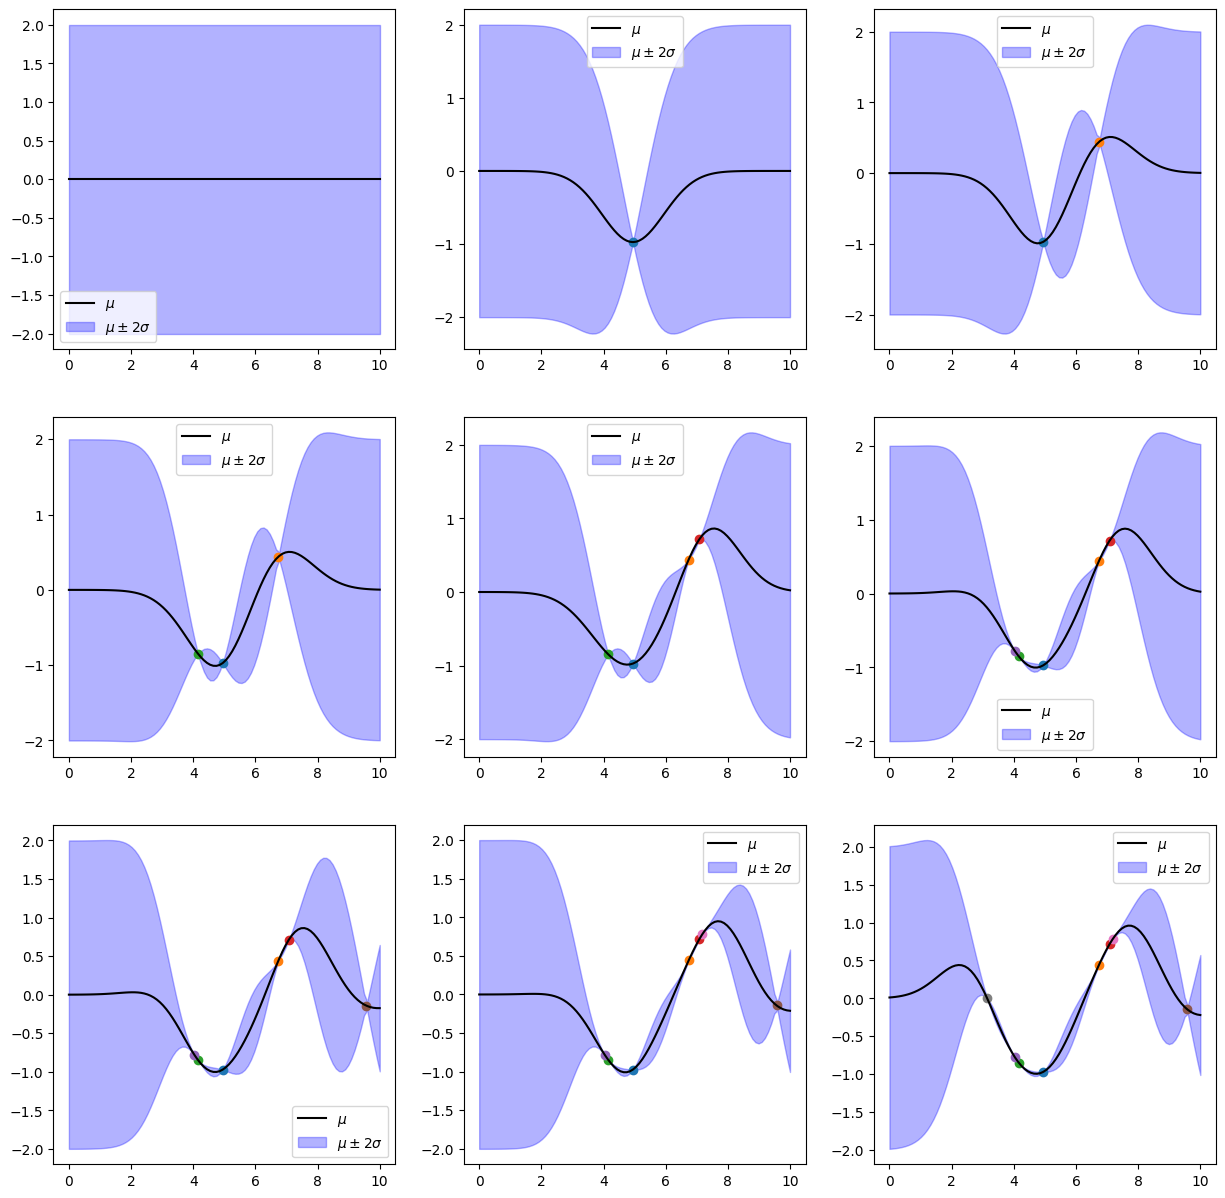

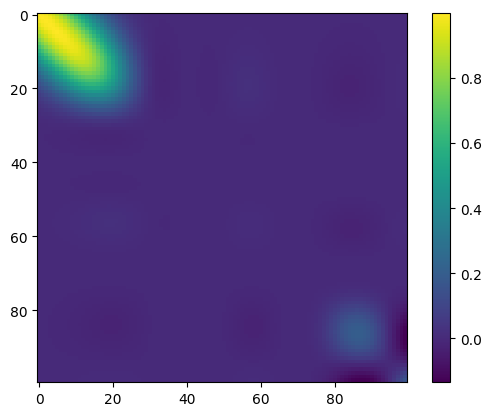

In [ ]:
m = np.zeros_like
k = rbf
gp = GaussianProcess(m=m, k=k)


fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

x_new = np.linspace(0, 10, 100)
gp.plot(axs.flat[0], x_new)
axs.flat[0].legend(loc=0)

xs = []
ys = []
for ax in axs.flat[1:]:
    x = np.random.random(1) * 10
    y = np.sin(x)
    gp.observe(x, y)

    gp.plot(ax, x_new)

    xs.append(x)
    ys.append(y)
    for x, y in zip(xs, ys):
        ax.scatter(x, y)

    ax.legend(loc=0)
plt.show()


fig, ax = plt.subplots()
img = gp.plot_k(ax, x_new)
plt.colorbar(img)
plt.show()